# Ternary data analysis

# used augment and class like in binary data

In [1]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import shutil
from sklearn.model_selection import train_test_split

import pandas as pd
from collections import Counter
import random
import seaborn as sns



Image_size = 96
Batch = 32
Random_seed = 42

# first image size i og used 256 and 128 but take to long :

In [ ]:
def focal_loss_sparse(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        
        # One-hot encode y_true
        y_true_one_hot = tf.one_hot(y_true, depth=y_pred.shape[-1])
        
        # Cross entropy
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        
        # Focal weight
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        
        return focal_weight * ce
    return loss

def apply_blur(img):
    img = tf.expand_dims(img, 0)  
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0) 

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))    
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights_Tri(ds):
    labels = np.concatenate([y.numpy() for _, y in ds.batch(512)])    
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    class_weights = dict(zip(classes, weights))
    print(f"Class weights: {class_weights}")
    return class_weights


def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [Image_size, Image_size])
    
    return image, label

In [10]:
train_Tri_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Tri/",
    validation_split=0.30,
    subset="training",
    seed=Random_seed, 
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=True  
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "Training_Tri/",
    validation_split=0.30,
    subset="validation",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=True  
)

val_size = int(0.5 * len(temp_ds))
val_Tri_raw = temp_ds.take(val_size)
test_Tri_raw = temp_ds.skip(val_size)

train_ds = (
    train_Tri_raw
    .cache() 
    .shuffle(5000, seed=Random_seed)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_Tri_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_Tri_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(train_p, train_l, test_p, test_l)

Found 39375 files belonging to 3 classes.
Using 27563 files for training.
Found 39375 files belonging to 3 classes.
Using 11812 files for validation.
Class 0: 0/243 leaked (0.0%)
Class 1: 0/243 leaked (0.0%)
Class 2: 0/243 leaked (0.0%)


# clearly extremely unbalanced data sets. had to be dealt with, as baseline compare model to see what no data engineernig does

In [4]:
model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling2D(),
    
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax') 
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss_sparse(gamma=2.0, alpha=0.25),  # use what you wrote
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',  # something that actually exists
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=compute_class_weights_Tri(train_ds.unbatch()),
    callbacks=callbacks
)

Class weights: {0: 0.5262122947689958, 1: 1.1026964314290286, 2: 5.187841144362883}
Epoch 1/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8703 - loss: 0.0352 - val_accuracy: 0.6996 - val_loss: 0.0591 - learning_rate: 1.0000e-04
Epoch 2/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9310 - loss: 0.0192 - val_accuracy: 0.8080 - val_loss: 0.0603 - learning_rate: 1.0000e-04
Epoch 3/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9401 - loss: 0.0155 - val_accuracy: 0.9170 - val_loss: 0.0185 - learning_rate: 1.0000e-04
Epoch 4/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9468 - loss: 0.0132 - val_accuracy: 0.9538 - val_loss: 0.0107 - learning_rate: 1.0000e-04
Epoch 5/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9531 - loss: 0.0115 - val_accuracy: 0.9646 - val_loss: 0.0085 - learning_rate: 1.0000e-04
Epoch 6/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9553 - loss: 0.0103 - val_accuracy: 0.9636 - val_loss: 0.0

In [5]:
true_labels = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model(images, training=False)
    true_labels.extend(labels.numpy())
    y_pred_prob.extend(preds.numpy())

true_labels = np.array(true_labels)
y_pred_prob = np.array(y_pred_prob)
pred_classes = np.argmax(y_pred_prob, axis=1)

loss, acc = model.evaluate(test_ds)
print(f"Test Loss:      {loss:.4f}")
print(f"Test Accuracy:  {acc:.4f}")
# Now your confusion matrix and report will be accurate
cm = confusion_matrix(true_labels, pred_classes)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    true_labels,
    pred_classes,
    target_names=train_Tri_raw.class_names  # use actual names, not hardcoded ones
    ))

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9695 - loss: 0.0078
Test Loss:      0.0078
Test Accuracy:  0.9695

Confusion Matrix:
[[3721    0   38]
 [   0 1765    0]
 [ 136    6  240]]

Classification Report:
              precision    recall  f1-score   support

        Fire       0.96      0.99      0.98      3759
        Lake       1.00      1.00      1.00      1765
     No_Fire       0.86      0.63      0.73       382

    accuracy                           0.97      5906
   macro avg       0.94      0.87      0.90      5906
weighted avg       0.97      0.97      0.97      5906



# clearly data leak takes place and affects output. First i remove duplicates. then move data to individual folders 

In [6]:
def remove_duplicates_smart(paths, labels, class_to_idx):
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    no_fire_idx = class_to_idx.get('No_Fire', 2) 
    
    print(f"Checking {len(paths)} files for duplicates...")
    for p, l in zip(paths, labels):
        try:
            with Image.open(p) as img:
                # Use phash to find visually identical images
                h = str(imagehash.phash(img, hash_size=8))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
                
        except:
            continue
    return clean_paths, clean_labels

base_dir = "Training_Tri/"
class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
class_to_idx = {name: i for i, name in enumerate(class_names)}

all_p, all_l = [], []
for class_name in class_names:
    c_path = os.path.join(base_dir, class_name)
    files = [os.path.join(c_path, f) for f in os.listdir(c_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_p.extend(files)
    all_l.extend([class_to_idx[class_name]] * len(files))

clean_p, clean_l = remove_duplicates_smart(all_p, all_l, class_to_idx)

# First, split into Training and Test (e.g., 20% for Test)
train_val_p, test_p, train_val_l, test_l = train_test_split(
    clean_p, clean_l, test_size=0.2, random_state=42, stratify=clean_l
)

# Now, get Validation FROM the new Training set (e.g., 15% of the remaining training data)
train_p, val_p, train_l, val_l = train_test_split(
    train_val_p, train_val_l, test_size=0.15, random_state=42, stratify=train_val_l
)

def move_to_folders(paths, labels, root_folder):
    for p, l in zip(paths, labels):
        dest_dir = os.path.join(root_folder, class_names[l])
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(dest_dir, os.path.basename(p)))

print("Moving files to Ternary folders...")
move_to_folders(train_p, train_l, "Ternary_Training")
move_to_folders(test_p, test_l, "Ternary_Test")
move_to_folders(val_p, val_l, "Ternary_Validation")

print(f"Done! Final counts -> Train: {len(train_p)}, Val: {len(val_p)}, Test: {len(test_p)}")

Checking 39375 files for duplicates...
Moving files to Ternary folders...
Done! Final counts -> Train: 6154, Val: 1086, Test: 1810


# data still to unbalanced. running it would cause huge variance in model. so will balance the folders and recheck data leakage

In [7]:
check_leakage_by_class(train_p, train_l, test_p, test_l)
# Undersample all classes to match the smallest class
from collections import Counter

counts = Counter(train_l)
print(f"Before balancing: {dict(counts)}")

min_count = min(counts.values())
print(f"Limiting each class to: {min_count} samples")

import random

train_p_orig, train_l_orig = list(train_p), list(train_l)
val_p_orig, val_l_orig = list(val_p), list(val_l)


print(f"Captured 'Original' Hashed Counts -> Train: {Counter(train_l_orig)}")

def balance_split(paths, labels, seed=Random_seed):
    counts = Counter(labels)
    min_count = min(counts.values())
    combined = list(zip(paths, labels))
    random.seed(seed)
    random.shuffle(combined)
    bal_p, bal_l = [], []
    class_seen = Counter()
    for p, l in combined:
        if class_seen[l] < min_count:
            bal_p.append(p)
            bal_l.append(l)
            class_seen[l] += 1
    return bal_p, bal_l

train_p, train_l = balance_split(train_p, train_l)
val_p,   val_l   = balance_split(val_p,   val_l)
test_p,  test_l  = balance_split(test_p,  test_l)

print(f"Train: {Counter(train_l)}")
print(f"Val:   {Counter(val_l)}")
print(f"Test:  {Counter(test_l)}")


Class 0: 0/1032 leaked (0.0%)
Class 1: 0/535 leaked (0.0%)
Class 2: 0/243 leaked (0.0%)
Before balancing: {0: 3506, 1: 1821, 2: 827}
Limiting each class to: 827 samples
Captured 'Original' Hashed Counts -> Train: Counter({0: 3506, 1: 1821, 2: 827})
Train: Counter({1: 827, 2: 827, 0: 827})
Val:   Counter({1: 146, 0: 146, 2: 146})
Test:  Counter({2: 243, 0: 243, 1: 243})


# then split data. but caused major data leakage so had to work around this. now test on basic model

In [8]:
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l)) 
    .shuffle(len(train_p), seed=Random_seed)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_p, val_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_p, test_l)) 
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

train_raw_for_weights = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
)

# Calculate weights
class_weights = compute_class_weights_Tri(train_raw_for_weights)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}



--- Running Experiment: Hashed + Weighted ---
Class weights: {0: 0.5850922228560563, 1: 1.1264872780523523, 2: 2.4804514308746475}
Results for Hashed + Weighted:
              precision    recall  f1-score   support

        Fire       0.50      1.00      0.67       243
        Lake       0.99      1.00      0.99       243
     No_Fire       0.00      0.00      0.00       243

    accuracy                           0.67       729
   macro avg       0.50      0.67      0.55       729
weighted avg       0.50      0.67      0.55       729


--- Running Experiment: Hashed + Downsampled ---


C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_clas

Results for Hashed + Downsampled:
              precision    recall  f1-score   support

        Fire       0.62      0.64      0.63       243
        Lake       0.98      1.00      0.99       243
     No_Fire       0.62      0.58      0.60       243

    accuracy                           0.74       729
   macro avg       0.74      0.74      0.74       729
weighted avg       0.74      0.74      0.74       729



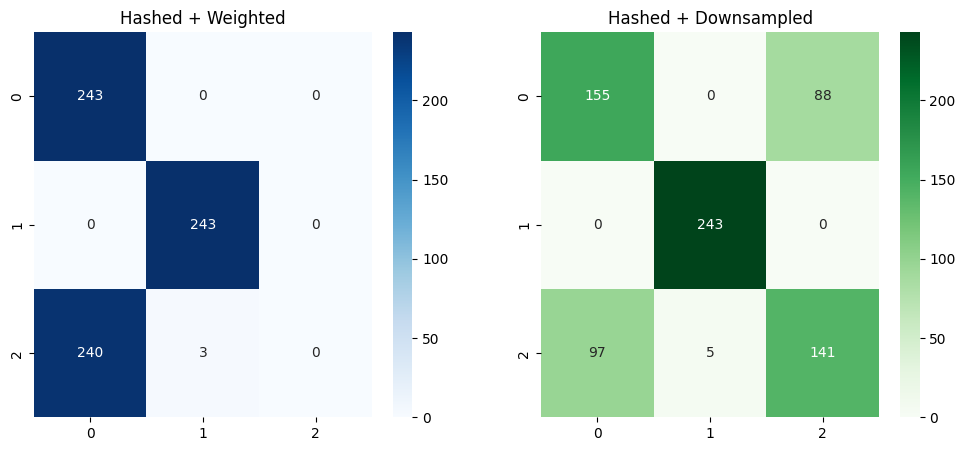

In [9]:
def run_experiment(train_p, train_l, val_p, val_l, test_p, test_l, experiment_name, use_weights=False):
    print(f"\n--- Running Experiment: {experiment_name} ---")
    
    # 1. Prepare Datasets
    def prepare_ds(p, l, is_training=False):
        ds = tf.data.Dataset.from_tensor_slices((p, l))
        ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        if is_training:
            ds = ds.shuffle(len(p)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        else:
            ds = ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
        return ds.batch(Batch).prefetch(tf.data.AUTOTUNE)

    curr_train_ds = prepare_ds(train_p, train_l, is_training=True)
    curr_val_ds = prepare_ds(val_p, val_l)
    curr_test_ds = prepare_ds(test_p, test_l)

    # 2. Define a fresh model instance
    model = keras.models.Sequential([
        keras.layers.Input(shape=(Image_size, Image_size, 3)),
        keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(1e-4), 
                  loss=focal_loss_sparse(gamma=2.0, alpha=0.25), 
                  metrics=['accuracy'])

    # 3. Calculate weights if needed
    weights = None
    if use_weights:
        weights = compute_class_weights_Tri(tf.data.Dataset.from_tensor_slices((train_p, train_l)).map(load_and_preprocess))

    # 4. Train
    model.fit(curr_train_ds, validation_data=curr_val_ds, epochs=15, 
              class_weight=weights, verbose=0)

    # 5. Evaluate
    y_true, y_pred = [], []
    for imgs, lbls in curr_test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(f"Results for {experiment_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    return confusion_matrix(y_true, y_pred)

# --- EXECUTION ---

# Scenario A: Hashed but Unbalanced (using class weights)
# Assumes train_val_p/l are the lists AFTER remove_duplicates_smart but BEFORE balance_split
cm_unbalanced = run_experiment(train_p_orig, train_l_orig, val_p_orig, val_l_orig, 
                               test_p, test_l, "Hashed + Weighted", use_weights=True)

# Scenario B: Hashed and Downsampled
# Assumes train_p/l are the lists AFTER balance_split
cm_balanced = run_experiment(train_p, train_l, val_p, val_l, 
                             test_p, test_l, "Hashed + Downsampled", use_weights=False)

# Compare Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_unbalanced, annot=True, fmt='d', ax=ax[0], cmap='Blues').set_title('Hashed + Weighted')
sns.heatmap(cm_balanced, annot=True, fmt='d', ax=ax[1], cmap='Greens').set_title('Hashed + Downsampled')
plt.show()

# Now i do the image hash and the downsampling and see how it compares to image hash and weights, making sure to image hash before data splitting

In [11]:
# Hash before splitting to ensure no leakage
base_dir = "Training_Tri/"
class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
class_to_idx = {name: i for i, name in enumerate(class_names)}

all_p, all_l = [], []
for class_name in class_names:
    c_path = os.path.join(base_dir, class_name)
    files = [os.path.join(c_path, f) for f in os.listdir(c_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_p.extend(files)
    all_l.extend([class_to_idx[class_name]] * len(files))

# Remove duplicates before splitting
clean_p, clean_l = remove_duplicates_smart(all_p, all_l, class_to_idx)

# Split into train, val, test
train_val_p, test_p, train_val_l, test_l = train_test_split(
    clean_p, clean_l, test_size=0.2, random_state=42, stratify=clean_l
)
train_p, val_p, train_l, val_l = train_test_split(
    train_val_p, train_val_l, test_size=0.15, random_state=42, stratify=train_val_l
)

# Balance train and val
train_p_bal, train_l_bal = balance_split(train_p, train_l)
val_p_bal, val_l_bal = balance_split(val_p, val_l)
test_p_bal, test_l_bal = balance_split(test_p, test_l)

# Run experiments
cm_weighted = run_experiment(train_p, train_l, val_p, val_l, test_p, test_l, "Hashed before split + Weighted", use_weights=True)
cm_balanced = run_experiment(train_p_bal, train_l_bal, val_p_bal, val_p_bal, test_p_bal, test_l_bal, "Hashed before split + Downsampled", use_weights=False)

# Note: There was a typo in val_p_bal above, it should be val_l_bal for the val labels in run_experiment.

# Corrected:
cm_balanced = run_experiment(train_p_bal, train_l_bal, val_p_bal, val_l_bal, test_p_bal, test_l_bal, "Hashed before split + Downsampled", use_weights=False)

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_weighted, annot=True, fmt='d', ax=ax[0], cmap='Blues').set_title('Hashed before split + Weighted')
sns.heatmap(cm_balanced, annot=True, fmt='d', ax=ax[1], cmap='Greens').set_title('Hashed before split + Downsampled')
plt.show()

Checking 39375 files for duplicates...

--- Running Experiment: Hashed before split + Weighted ---
Class weights: {0: 0.5850922228560563, 1: 1.1264872780523523, 2: 2.4804514308746475}
Results for Hashed before split + Weighted:
              precision    recall  f1-score   support

        Fire       0.81      1.00      0.90      1032
        Lake       0.99      1.00      1.00       535
     No_Fire       0.00      0.00      0.00       243

    accuracy                           0.87      1810
   macro avg       0.60      0.67      0.63      1810
weighted avg       0.76      0.87      0.81      1810


--- Running Experiment: Hashed before split + Downsampled ---


C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_clas

UnimplementedError: Graph execution error:

Detected at node compile_loss/loss/Cast defined at (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\runpy.py", line 196, in _run_module_as_main

  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\runpy.py", line 86, in _run_code

  File "C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\ipykernel\kernelapp.py", line 7